In [2]:
import pandas as pd
import numpy as np
from pathlib import Path


logs = Path("../logs")
tables = Path("../tables")

In [3]:
df_dd = pd.read_csv(logs / "dd_run/data_frame.csv")
df_ev = pd.read_csv(logs / "evaluate/data_frame.csv")

dd_best = df_dd.groupby(
    [
        "boundary",
        "strategy",
        "detector",
    ]
)["dd.f1"].mean()
best_methods = dd_best.groupby(["boundary", "strategy"]).idxmax()
best_detectors = (
    df_ev[["boundary", "strategy", "detector_label"]]
    .apply(tuple, axis=1)
    .isin(best_methods.values)
)
mask = (df_ev["detector_label"] == "oracle") | (
    df_ev["detector_label"] == "ADWIN_JOINT"
)
df_ev.loc[best_detectors, "detector_label"] = "Best"
df_ev = df_ev[mask | best_detectors]
df_ev["detector_label"] = df_ev["detector_label"].replace("ADWIN_JOINT", "ADWIN*")

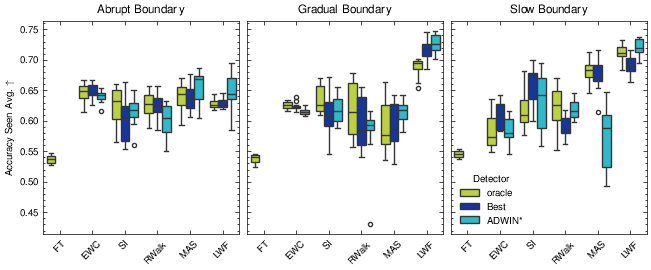

In [4]:
import seaborn as sns
from matplotlib import pyplot as plt
import scienceplots as _  # noqa: F401
from atab10 import atab10

plt.style.use(["science", "nature"])

width = 390
aspect = 1 + 2**0.5
scale = 1.2 / 72
figsize = (width * scale, (width * scale) / aspect)

detector_palette = {
    "oracle": atab10(5),
    "ADWIN*": atab10(7),
    "Best": atab10(9),
}


def plot_boxplots(df: pd.DataFrame) -> None:
    boundaries = sorted(df["boundary"].dropna().unique())
    fig, axes = plt.subplots(
        1, len(boundaries), figsize=figsize, sharey=True, constrained_layout=True
    )

    # Handle the single-boundary case so `axes` is always iterable
    if len(boundaries) == 1:
        axes = [axes]

    for idx, (ax, boundary) in enumerate(zip(axes, boundaries)):
        mask = df["boundary"] == boundary
        sns.boxplot(
            data=df[mask],
            x="strategy",
            y="ocl.accuracy_seen_avg",
            hue="detector_label",
            ax=ax,
            palette=detector_palette,
            legend=idx == len(boundaries) - 1,
            order=["FT", "EWC", "SI", "RWalk", "MAS", "LWF"],
        )
        ax.set_title(f"{boundary.capitalize()} Boundary")
        ax.tick_params(axis="x", rotation=45)
        ax.set_xlabel("")

    # Keep legend only on the last subplot to reduce clutter
    for ax in axes[:-1]:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    if axes[-1].legend_ is not None:
        axes[-1].legend_.set_title("Detector")

    for ax in axes:
        ax.xaxis.set_minor_locator(plt.NullLocator())

    axes[0].set_ylabel(r"Accuracy Seen Avg. $\uparrow$")

    # Save figure
    fig.savefig("../fig/strategy_performance.pdf")


plot_boxplots(df_ev.reset_index())

In [5]:
from typing import Optional, Literal
from jinja2 import Template

_template = Template(
    r"{% if font_style %}\{{font_style ~ '{'}}{% endif %}"
    r"{{ '{:.{}f}'.format(mean, ndigits) }}\tiny{$\pm${{ '{:.{}f}'.format(std, ndigits) ~ '}' }}"
    r"{% if font_style %}}{% endif %}"
)

TexFontStyle = Literal["textmd", "textbf", "textup", "textit", "textsl", "textsc"]


def format_column(
    df: pd.DataFrame | pd.Series,
    mean_col="mean",
    std_col="std",
    min_style: Optional[TexFontStyle] = None,
    max_style: Optional[TexFontStyle] = None,
    ndigits=3,
    nan_str="N/A",
) -> pd.DataFrame | pd.Series:
    col_max = df[mean_col].max()
    col_min = df[mean_col].min()

    def _func(row: pd.Series) -> str:
        mean = float(row[mean_col])
        std = float(row[std_col])
        font_style = None

        if pd.isna(mean) or pd.isna(std):
            return nan_str

        # Perform the comparison using the same precision as the formatted output
        if max_style and round(mean, ndigits) == round(col_max, ndigits):
            font_style = max_style
        elif min_style and round(mean, ndigits) == round(col_min, ndigits):
            font_style = min_style

        return _template.render(
            mean=mean,
            std=std,
            font_style=font_style,
            ndigits=ndigits,
        )

    return df.apply(_func, axis=1)

In [6]:
from pathlib import Path

BOUNDARY_AGNOSTIC = {"FT"}

AGGREGATIONS = ("mean", "std")

df_grouped = df_ev.groupby(
    ["boundary", "strategy", "detector", "detector_label"]
).aggregate(AGGREGATIONS)


def latex_table(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # index to columns
    df.reset_index(inplace=True)
    # Move FT rows to the end of the table, since it is boundary-agnostic
    boundary_agnostic_mask = df["strategy"].isin(BOUNDARY_AGNOSTIC)
    df = pd.concat(
        [df[~boundary_agnostic_mask], df[boundary_agnostic_mask]], ignore_index=True
    )

    # Ignore drift detection metrics (dd.*) for the oracle detector, since they are not
    # meaningful
    oracle_mask = df["detector"] == "oracle"
    dd_cols = [col for col in df.columns if col[0].startswith("dd.")]
    df.loc[oracle_mask, dd_cols] = np.nan

    ndigits_percent = 1
    UP = r"$\uparrow$"
    DOWN = r"$\downarrow$"

    # Create a copy of the data frame with just the index
    df_formatted = pd.DataFrame(index=df.index)
    df_formatted["Strategy"] = df["strategy"]
    df_formatted["Detector"] = df["detector_label"].replace(
        {"ADWIN_JOINT": "ADWIN*", "oracle": "Oracle"}
    )

    df_formatted[f"Acc. {UP}"] = format_column(
        df["ocl.accuracy_seen_avg"] * 100,
        max_style="textbf",
        ndigits=ndigits_percent,
    )
    df_formatted[r"Acc$_{ttt}$ " + UP] = format_column(
        df["ttt.accuracy"],
        max_style="textbf",
        ndigits=ndigits_percent,
    )
    df_formatted[f"FWT {UP}"] = format_column(
        df["ocl.forward_transfer"] * 100,
        max_style="textbf",
        ndigits=ndigits_percent,
    )
    df_formatted[f"BWT {UP}"] = format_column(
        df["ocl.backward_transfer"] * 100,
        max_style="textbf",
        ndigits=ndigits_percent,
    )
    df_formatted[f"F1 {UP}"] = format_column(
        df["dd.f1"],
        max_style="textbf",
        ndigits=ndigits_percent,
    )
    df_formatted[f"MDT {DOWN}"] = format_column(
        df["dd.mdt"],
        min_style="textbf",
        ndigits=0,
    )

    return df_formatted


for b in sorted(df_ev["boundary"].unique()):
    _table_df = latex_table(df_grouped.loc[b])
    _table_latex = _table_df.to_latex(
        index=False,
        escape=False,
        na_rep="N/A",
    )
    table_path = Path(f"../table/strategy_{b}.tex")
    print(f"Saving {table_path}")
    table_path.write_text(_table_latex)

Saving ../table/strategy_abrupt.tex
Saving ../table/strategy_gradual.tex
Saving ../table/strategy_slow.tex
